In [1]:
#from kaggle.api.kaggle_api_extended import KaggleApi

#api = KaggleApi()
#api.authenticate()

#api.dataset_download_files("rjmanoj/credit-card-customer-churn-prediction", unzip=True)

In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns=["RowNumber","CustomerId","Surname"], inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df =pd.get_dummies(df, columns=["Geography","Gender"], drop_first=True)

In [9]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [10]:
x = df.drop (columns = ["Exited"])
y= df["Exited"].values
import sklearn.model_selection as train_test_split
x_train,x_test,y_train,y_test = train_test_split.train_test_split(x,y, test_size=0.2, random_state=42)


In [11]:
x_train.shape

(8000, 11)

In [12]:
y_train.shape

(8000,)

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_trf= sc.fit_transform(x_train)
x_test_trf = sc.transform(x_test)

In [14]:
x_train_trf.shape

(8000, 11)

In [15]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model =Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\rohan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
his =model.fit(x_train_trf,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5100 - loss: 0.7203 - val_accuracy: 0.7987 - val_loss: 0.5649
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.5267 - val_accuracy: 0.7987 - val_loss: 0.4970
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4949 - val_accuracy: 0.7987 - val_loss: 0.4805
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4840 - val_accuracy: 0.7987 - val_loss: 0.4705
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.4757 - val_accuracy: 0.7987 - val_loss: 0.4616
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.4678 - val_accuracy: 0.7987 - val_loss: 0.4531
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.4600 - val_accuracy: 0.7987 - val_loss: 0.4450
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7933 - loss: 0.4527 - val_accu

In [20]:
model.layers[0].get_weights()

[array([[ 0.15522407,  0.23917012,  0.33920908, -0.42574596, -0.08978923,
         -0.13246742, -0.06719128, -0.36048758,  0.12992503,  0.25260946,
         -0.12053664],
        [-2.4262917 ,  0.3542259 , -0.46036282, -0.49634457, -0.2682091 ,
         -2.432413  , -2.370614  ,  0.34787917, -2.076252  , -2.1780431 ,
         -0.4130727 ],
        [-0.23611455,  0.25959215, -0.09777017, -0.02632385, -0.15174693,
         -0.0831086 ,  0.43987003, -0.14592397,  0.0384049 , -0.36792365,
         -0.13189308],
        [-0.27538723, -1.6929533 , -0.36884624, -0.20498182,  0.5914966 ,
         -0.32830805,  0.38685918, -0.70909774, -0.18302803, -0.3500877 ,
         -0.73692346],
        [-0.20397139, -1.5548527 ,  0.65137756,  0.53270406,  3.510379  ,
         -0.19867711, -0.5018077 , -0.5329655 , -0.44424093, -0.23432662,
          0.7331004 ],
        [-0.3450749 ,  0.05339344, -0.6205321 , -0.2570425 , -0.23590948,
         -0.21657227,  0.3072893 , -0.16928028, -0.02579763, -0.6086302

In [21]:
model.layers[1].get_weights()

[array([[-0.827632  ,  0.2447057 , -0.5656212 ,  0.256569  , -0.36878416,
          1.1976724 ,  0.10821544, -0.3434014 , -0.89088714, -0.12296075,
          0.10908975],
        [-0.60965085,  0.6923362 , -1.4539315 ,  0.9339253 , -0.7205967 ,
          1.292602  ,  0.9336261 , -0.80532074, -0.81858987, -0.96190536,
         -0.1265005 ],
        [ 1.010241  , -1.2002354 ,  0.61934257, -0.74749875,  1.1209829 ,
         -0.63991654, -1.1866304 ,  0.5913319 ,  1.0492762 ,  0.7284704 ,
          0.24265231],
        [ 1.1308825 , -1.022447  ,  0.44205278, -0.65986866,  1.1702381 ,
         -0.97334903, -0.68868935,  0.32960483,  1.113496  ,  0.81893915,
          1.0060483 ],
        [-1.9080448 ,  1.8311961 , -0.24291311,  1.4511447 , -1.5331641 ,
          0.43950424,  1.926377  , -0.9060238 , -0.7946284 , -1.7723248 ,
         -2.2029562 ],
        [ 0.12439455,  0.659686  , -1.1007476 ,  0.31445503, -0.6001496 ,
          1.097348  ,  0.24707444, -0.19901577, -0.826163  ,  0.1261756

In [22]:
y_pred =model.predict(x_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [23]:
y_pred

array([[0.07744319],
       [0.06916697],
       [0.19909203],
       ...,
       [0.7327635 ],
       [0.16535212],
       [0.21702798]], dtype=float32)

In [24]:
y_pred =y_pred.argmax(axis=-1)

In [25]:
from sklearn.metrics import accuracy_score
acc =accuracy_score(y_test,y_pred)
print("accuracy is ",acc)

accuracy is  0.8035


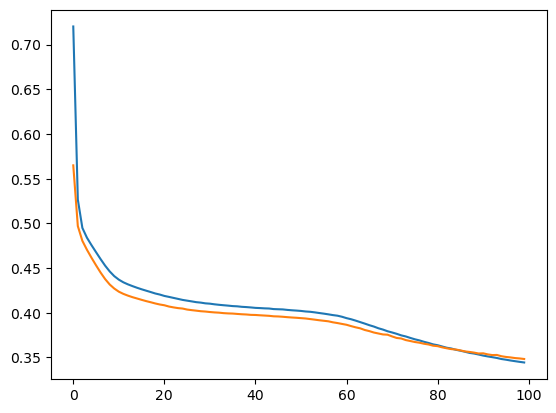

In [26]:
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])

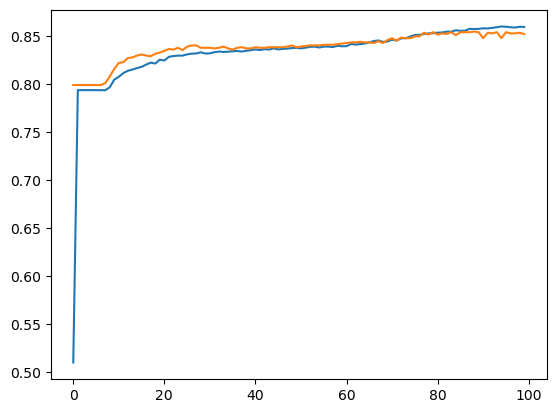

In [27]:
plt.plot(his.history['accuracy'])
plt.plot(his.history['val_accuracy'])